# 5.7 — Gradient Boosting & XGBoost Regression
## Predicting Crop Yield Across Tamil Nadu Farms

---

### Who This Notebook Is For

This notebook assumes you know what a Decision Tree is and what a loss function is. Everything else — Gradient Boosting, XGBoost, gradients, Hessians, regularisation — is built from scratch here. By the end, you will know not just how to use XGBoost but exactly why every design decision inside it exists.

---

### The Story

Ravi is a data scientist at the Tamil Nadu Department of Agriculture. His team has data on 500 farming plots across the state — rainfall, fertilizer used, soil quality score, temperature, and farm size.

Their goal: **predict crop yield (kg per hectare)** so the government can:
- Plan procurement targets district-by-district
- Identify underperforming plots before harvest
- Recommend interventions (more fertilizer, irrigation) where needed

They tried plain Gradient Boosting — it worked but was slow and started overfitting. A colleague suggests XGBoost. Ravi's team wants to understand **why** XGBoost is better before they switch.

This notebook answers that question completely.

---

# PART 1 — GRADIENT BOOSTING: THE FOUNDATION

---

## 1.1 — The Core Question That Creates Boosting

You have a dataset. You train a model. It makes predictions. Some are wrong.

Now ask this:

> **Can we take a bunch of weak, dumb models and combine them so the combination is powerful?**

Random Forest answered this by training trees in **parallel** and **averaging** their predictions.

Gradient Boosting answers differently:

> Train them **sequentially** — where each new model fixes the mistakes of the previous one.

That one difference is everything.

---

## 1.2 — The Analogy: A Committee of Error-Correctors

Imagine Ravi's team has a junior analyst, **Arjun**, who estimates crop yield for each farm plot. His first guess is rough — off by about 80 kg/ha on average.

Then a second analyst, **Meena**, doesn't look at the original yield target. She only looks at **Arjun's mistakes** — the gap between his prediction and the real yield. She tries to predict that gap.

Then a third analyst, **Kumar**, looks at the remaining gap after Meena's correction. And so on.

Each analyst is a **weak learner** — not powerful alone. But combined, each one covers what the previous ones missed.

**That is Gradient Boosting.**

---

## 1.3 — Step-by-Step Walkthrough

True yield for one farm plot = **500 kg/ha**.

**Round 1:**  
Starting prediction = mean of all yields = **420 kg/ha**  
Error = 500 − 420 = **80 kg/ha**

**Round 2:**  
Tree 2 does NOT try to predict 500. It only tries to predict the gap: **80**.  
Tree 2 predicts **55**.  
Update: new prediction = 420 + 0.1 × 55 = **425.5**  
(0.1 = learning rate — we take a small, careful step, not the full correction)  
New error = 500 − 425.5 = **74.5**

**Round 3:**  
Tree 3 tries to predict **74.5**. And so on for 100, 200, 300 trees.

Each tree is small and weak — it only has to predict the **remaining gap**, not the full target.

**Final prediction formula:**
$$\hat{y} = T_1 + \eta \cdot T_2 + \eta \cdot T_3 + \ldots + \eta \cdot T_n$$

Where η (eta) = learning rate. Each tree contributes a small correction. Final answer = their **SUM** (not average — that's Random Forest).

---

## 1.3b — The Target Column LITERALLY Becomes the Residual

This is the most important mechanical detail to understand in Gradient Boosting.

In Round 1, the dataset looks normal:

```
rainfall | fertilizer | soil | temperature | farm_size | TARGET
---------|------------|------|-------------|-----------|-------
   120   |     80     |  7   |     28      |    5      |  500
   90    |     60     |  5   |     30      |    3      |  380
   150   |    100     |  9   |     26      |    8      |  620
```

Tree 1 trains on the real target. Predictions come out as 420, 310, 540.

**In Round 2, the TARGET COLUMN IS REPLACED with residuals:**

```
rainfall | fertilizer | soil | temperature | farm_size | TARGET (now residuals)
---------|------------|------|-------------|-----------|----------------------
   120   |     80     |  7   |     28      |    5      |   80   ← 500-420
   90    |     60     |  5   |     30      |    3      |   70   ← 380-310
   150   |    100     |  9   |     26      |    8      |   80   ← 620-540
```

Tree 2 trains on THIS. Same features. Completely different target. It has no idea what the original yields were — it only sees the gaps.

**In Round 3, the target column is replaced AGAIN with the new residuals.**

This is what 'adding a function that reduces loss' means:
```
Step 1 — compute residuals (what's left to predict)
Step 2 — train a tree with residuals as the target column
Step 3 — add that tree's output × learning rate to the current prediction
Step 4 — compute new residuals
Step 5 — repeat
```

---

## 1.3c — Why Multiply by Learning Rate Instead of Adding the Full Residual?

If Tree 2 predicts the residual is 80 and we add the full 80 — we've assumed that one shallow tree perfectly estimated the remaining gap. But trees are weak and noisy. Adding the full prediction means we overshoot.

Small learning rate = take a cautious step. Even if Tree 2 is slightly wrong, we only add 10% of its prediction. The remaining gap gets corrected gradually by Trees 3, 4, 5...

```
Large learning rate → fewer trees needed → risky, overshoots, overfits
Small learning rate → more trees needed → stable, generalises better
```

This is why `learning_rate=0.01` with `n_estimators=2000` often beats `learning_rate=0.1` with `n_estimators=200` — more careful steps, more corrections, better final result.

---

## 1.4 — What Is a Residual? And Why Is It Called GRADIENT Boosting?

This is the most important conceptual piece in this notebook. Read it carefully.

### What Is a Gradient?

A gradient = the derivative of a function. It tells you which direction makes the function **increase**.

If you want to **minimise** something (like loss), you move in the **opposite** direction of the gradient. That's gradient descent.

---

### Gradient Descent in Linear Regression (Familiar Ground)

In Linear Regression, prediction = **ŷ = w₁x₁ + w₂x₂ + ...**

The loss function is:
$$\text{Loss} = \frac{1}{2}(y - \hat{y})^2 = \frac{1}{2}(y - (w_1x_1 + w_2x_2))^2$$

Notice: **w is INSIDE the formula** because ŷ = wx. When you differentiate loss with respect to w, you need the chain rule:
$$\frac{\partial \text{Loss}}{\partial w_1} = -(y - \hat{y}) \cdot x_1$$

You then update: **w = w − learning_rate × gradient**

After many such steps, gradient → 0. That's the minimum. Training stops.

---

### Gradient Boosting Has No Weights

In Gradient Boosting, there are no weights w. There is no equation ŷ = wx.  
ŷ is just whatever the current ensemble of trees predicts. It is a number.

So the question becomes: **how do we improve ŷ directly?**

We ask: how does loss change when I change **ŷ** directly — not w, but ŷ itself?

$$\frac{\partial \text{Loss}}{\partial \hat{y}} = \frac{\partial}{\partial \hat{y}} \frac{1}{2}(y - \hat{y})^2 = -(y - \hat{y})$$

The gradient w.r.t. ŷ = **−(y − ŷ)**

The **negative** gradient = **+(y − ŷ)** = the **residual**.

For MSE loss: **negative gradient = residual**. They are mathematically the same thing.

So when we train the next tree on residuals, we are doing gradient descent — but instead of updating a weight number, we are adding a whole **tree** (a function) that points in the direction of improvement.

---

### Why This Generalisation Matters

For MSE: negative gradient = y − ŷ (simple subtraction).  
For log loss (classification), MAE, Huber loss — the gradient formula is different.  
But the boosting loop stays exactly the same:
1. Compute gradient of loss w.r.t. ŷ
2. Train next tree to predict the negative gradient
3. Add it to the ensemble

By framing it as gradient, Gradient Boosting works with **any differentiable loss function**.  
"Fitting residuals" is just the MSE special case. That's where the name comes from.

| | Linear Regression | Gradient Boosting |
|---|---|---|
| What we optimise | weights w | predictions ŷ directly |
| Differentiate w.r.t. | w (w is inside ŷ = wx) | ŷ itself |
| Gradient formula | −(y−ŷ)·x | −(y−ŷ) |
| How we update | w = w − η × gradient | add a new tree |
| Space | parameter space | function space |
| Destination | gradient → 0, weights converge | residuals → 0, ensemble converges |

---

## 1.5 — Weaknesses of Plain Gradient Boosting

1. **Slow** — trees are built one by one sequentially. No parallelism in split-finding.
2. **Overfitting** — controlled only through `max_depth` and `learning_rate` — blunt tools.
3. **Missing values** — must handle manually before training.
4. **Expensive split-finding** — checks every possible threshold for every feature at every node.

---

# PART 2 — XGBOOST: THE UPGRADE

---

## 2.1 — Same Core Idea, Smarter Execution

XGBoost keeps the sequential boosting loop. Each tree still corrects the errors of the previous ensemble. But it changes **how** it builds each tree — at every single split decision.

---

## 2.1b — Why Not Use Log Loss for Regression?

Log loss is designed for **probability outputs** — values between 0 and 1:
```
Log Loss = -[y·log(ŷ) + (1-y)·log(1-ŷ)]
```

This only makes sense when y is 0 or 1 and ŷ is a probability between 0 and 1.

In regression, y = 500 kg/ha. You can't plug 500 into that formula meaningfully. The output is a raw number with no upper bound — not a probability.

```
Classification → output is probability (0 to 1)   → log loss works
Regression     → output is a number (0 to ∞)      → MSE works
```

XGBoost uses log loss automatically when you set `objective='binary:logistic'`. For regression it uses MSE by default (`objective='reg:squarederror'`). Same algorithm, different loss function.

---

## 2.2 — Upgrade 1: The Hessian (Second Derivative)

Plain GB uses only the **gradient** (first derivative) to decide splits.

XGBoost uses a Taylor expansion to use both:
- **g** = gradient (first derivative) — direction of error
- **h** = Hessian (second derivative) — curvature of error

**What is a second derivative, simply?**
- First derivative: how fast is the loss changing?
- Second derivative: how fast is **that rate** changing?

**The driving analogy:**  
You're driving from Chennai to Mumbai. You want to reach the lowest point (minimum loss).
- Gradient = your current speed and direction (80 km/h northward)
- Hessian = your acceleration (slowing down at 10 km/h per minute)

With only speed, you don't know if you're about to stop or keep going.  
With speed AND acceleration, you predict exactly where you'll be next and take a smarter step.

**The bowl shape:**
```
Loss
  |      *         
  |    *   *       
  |  *       *     
  |*           *   
  |_____________   
        ŷ →        
        ↑          
      minimum      
```
- Gradient tells you: slope is going downward (direction)
- Hessian tells you: the curve is bending upward — it's a bowl, not a straight slope
- With both, you take a precise step toward the bottom without overshooting

**The Taylor Expansion:**
$$\text{Loss}(\hat{y} + \Delta) \approx \text{Loss}(\hat{y}) + g \cdot \Delta + \frac{1}{2} h \cdot \Delta^2$$

Plain GB uses only the first two terms. XGBoost uses all three.

With both g and h, XGBoost computes the **exact gain** from any split:
$$\text{Gain} = \frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L+G_R)^2}{H_L+H_R+\lambda}$$

Read it as: Left score + Right score − Parent score = how much did this split help?  
If Gain > threshold → split. Otherwise → stop. Plain GB has no such formula.

---

## 2.2b — What Is 'The Split' and How Does the Gain Formula Actually Work?

### What is a split?

Say you're building one tree inside XGBoost. You have this data:

```
rainfall | residual (target)
---------|------------------
   60    |   80
   90    |   75
  120    |   30
  150    |   25
  180    |   20
```

The tree needs to decide: where do I draw the line to split this data?

```
Split option A: rainfall < 90  → left: [60,90], right: [120,150,180]
Split option B: rainfall < 120 → left: [60,90,120], right: [150,180]
Split option C: rainfall < 150 → left: [60,90,120,150], right: [180]
```

For each option it asks: does this split reduce loss better than not splitting?
The Gain formula answers this.

---

### The Gain Formula — Every Symbol Explained

```
Gain = GL²/(HL+λ) + GR²/(HR+λ) - (GL+GR)²/(HL+HR+λ) - γ
       ───────────   ───────────   ─────────────────────   ─
       left score    right score   parent score (before)   cost of splitting
```

**G = sum of gradients (residuals) in that group**
**H = sum of hessians in that group. For MSE, hessian=1 per point, so H = count of points**
**λ = L2 regularisation — added to H, shrinks leaf scores**
**γ = minimum gain required — penalty for making the split at all**

If Gain > 0 → split improves predictions → make the split  
If Gain ≤ 0 → split not worth it → stay as leaf

### Concrete Example — Split B: rainfall < 120

```
Left group (rainfall < 120):   residuals = [80, 75]
Right group (rainfall ≥ 120):  residuals = [30, 25, 20]

GL = 80+75 = 155       HL = 2   (2 points)
GR = 30+25+20 = 75     HR = 3   (3 points)
λ = 3,  γ = 1

GL²/(HL+λ)         = 155²/(2+3)      = 24025/5   = 4805
GR²/(HR+λ)         = 75²/(3+3)       = 5625/6    = 937.5
(GL+GR)²/(HL+HR+λ) = 230²/(2+3+3)   = 52900/8   = 6612.5

Gain = 4805 + 937.5 - 6612.5 - 1 = -871
```

Negative → split blocked.

XGBoost tries ALL split candidates and picks the one with the highest positive gain.
If no split has positive gain → node becomes a leaf.

### Score = G²/H — where does this come from?

The optimal leaf value for any group is: `w* = -G/(H+λ)`

For MSE with no λ: `w* = -G/H = -(sum of residuals)/(count) = mean of residuals`

This makes sense — the best prediction for a group is the mean of what it needs to predict.

The score G²/H is the loss improvement from using this optimal leaf value.
Higher G²/H = large residuals that can be reduced = splitting here helps a lot.

---

### How Hessian Captures Uncertainty

```
Score = G²/(H+λ)
```

If H is large (many points) → score is smaller → XGBoost less aggressive about splitting  
If H is small → score is larger — but λ prevents overconfidence from tiny groups

For MSE, H = count of points. A leaf with 3 rows gets divided by 3+λ.  
A leaf with 300 rows gets divided by 300+λ — λ barely changes anything for large groups.

**This is what 'gain relative to how uncertain we are' means — H is the uncertainty measure.**

---

## 2.3 — Upgrade 2: Built-in Regularisation

Plain GB: control overfitting only through `max_depth` and `learning_rate`.  
XGBoost: bakes regularisation into the objective itself:

$$\text{Objective} = \text{Loss} + \gamma T + \frac{1}{2}\lambda \sum w_j^2 + \alpha \sum |w_j|$$

- **γ (gamma):** minimum gain to make any split — automatic pruning
- **λ (lambda):** L2 penalty on leaf values — shrinks them, Ridge-like
- **α (alpha):** L1 penalty on leaf values — can zero them out, Lasso-like
- **T:** number of leaves — penalises complex trees

Every split justifies itself against this penalty. Trees cannot grow freely.

---

## 2.3b — Why Penalise the Leaf Score? It's the Predicted Value!

This is the right question to ask. The leaf score IS the prediction — why reduce it?

### The Problem — Small Leaves Are Unreliable

Say 3 rows land in a leaf with residuals: 80, 75, 85.

```
Leaf score (plain GB) = mean = (80+75+85)/3 = 80
```

The tree says: 'for any row landing here, add 80 to the current prediction.'

But those 3 rows are a tiny noisy sample. The true residual for this type of row might be 62 — not 80. The tree estimated 80 from 3 rows and became overconfident.

This overconfidence is what causes overfitting.

### What λ Does — Acts as Fake Rows Pulling Toward Zero

Without λ:  `w* = -G/H = -240/3 = 80`  
With λ=3:   `w* = -G/(H+λ) = -240/(3+3) = 40`

λ adds fake rows with residual=0 to the denominator:
```
Effective mean = (80+75+85+0+0+0) / (3+3) = 240/6 = 40
```

The penalty pulls the leaf toward zero — not because 40 is more accurate, but because the tree is saying: 'I only have 3 rows, I shouldn't be fully confident. Let me be conservative.'

```
Small leaf (3 rows):   heavily shrunk — low confidence, rightly so
Large leaf (300 rows): barely shrunk — high confidence, rightly so
```

### 'But predicting less and more affects us the same amount — undershoot is still wrong'

True for a single row. But λ is not designed for one row — it's designed for the average across all rows across all rounds.

Without λ: leaf confidently predicts 80 from 3 noisy rows. On new data where true residual=55 → error=25. Where true residual=105 → error=25. The leaf was estimated from noise, so it's wrong in both directions with high variance.

With λ: leaf conservatively predicts 40. It under-corrects in every round — but the remaining gap gets picked up by the NEXT tree.

```
Round 2 with λ: adds 40, residual = 40 remaining
Round 3 with λ: adds 20, residual = 20 remaining  
Round 4 with λ: adds 10, residual = 10 remaining
...gradually and reliably corrects...
```

Without λ, one overconfident tree 'solves' training data in a few rounds but fails on new data. With λ, the correction is spread across many rounds — slower but more reliable.

**λ doesn't guarantee less error on every single row. It guarantees less error on average by reducing the variance of leaf score estimates from small samples.**

### The Three Regularisers — Where Each One Acts

```
γ → controls the SPLIT DECISION   — should this split exist at all?
λ → controls the LEAF VALUE       — how much should this leaf predict?
α → controls the LEAF VALUE       — should this leaf predict anything at all?
```

γ and max_depth both produce shallower trees — but differently:
```
max_depth=2 → blindly stops at level 2, no matter what gain exists
γ=large     → stops when gain isn't worth it — smarter, more selective
```

Large γ blocks deep splits first — because deep splits have smaller groups → smaller G values → smaller gain → can't overcome large γ. So γ naturally prunes from the bottom up.

---

## 2.4 — Upgrade 3: Handles Missing Values

At every split, XGBoost tries routing missing values both left and right. Whichever direction reduces loss more becomes the **default direction**. The model learns what to do with missing data — no preprocessing needed.

---

## 2.5 — Upgrade 4: Speed (Histogram Approximation)

Plain GB: checks every threshold for every feature at every node (up to 10,000 thresholds on large data).  
XGBoost: bins features into ~256 buckets. Checks only 256 thresholds. Same quality split, fraction of the time.

---

## 2.6 — Upgrade 5: Subsampling

- `subsample=0.8`: each tree sees 80% of rows
- `colsample_bytree=0.8`: each tree sees 80% of features

Adds randomness, reduces overfitting — same logic as Random Forest's bootstrap, inside a boosting framework.

---

## 2.9 — One Complete XGBoost Round — All Upgrades Active

This walks through every single step of one round with 6 farm plots. All 5 upgrades are active simultaneously.

### The Data

```
Plot | rainfall | fertilizer | yield | current pred | residual (g) | hessian (h)
-----|----------|------------|-------|--------------|--------------|------------
  1  |    60    |     40     |  200  |     420      |    -220      |      1
  2  |    70    |     50     |  220  |     420      |    -200      |      1
  3  |   120    |     80     |  480  |     420      |     -60      |      1
  4  |   130    |     90     |  500  |     420      |     -80      |      1
  5  |   180    |    100     |  750  |     420      |    -330      |      1
  6  |   190    |    110     |  770  |     420      |    -350      |      1
```

Starting prediction = mean of all yields = 420 (Tree 1 always predicts the mean).  
Residual = yield - prediction. Hessian = 1 for every point (MSE loss).

### Upgrade 1 Active — Histogram (before split-finding)

XGBoost compresses rainfall (60-190) into 256 bins.  
Instead of checking every unique value, it only checks 256 bin boundaries.  
With real data (10,000 rows, 500 unique values) → 256 bins instead of 500 = 2x faster per feature.

### Upgrade 2 Active — Subsampling (before this tree was built)

subsample=0.6 → randomly picked 4 of 6 plots  
colsample_bytree=0.6 → randomly picked 1 of 2 features (say: rainfall only)  
Tree was built on this random subset — prevents memorising full training data.

### Upgrade 3 Active — Gain Formula with Hessian (split evaluation)

XGBoost tries rainfall < 150 (λ=3, γ=1):

```
Left group (rainfall < 150):   Plots 1,2,3,4
  GL = (-220)+(-200)+(-60)+(-80) = -560
  HL = 4

Right group (rainfall ≥ 150):  Plots 5,6
  GR = (-330)+(-350) = -680
  HR = 2

GL²/(HL+λ) = 560²/(4+3) = 313600/7  = 44800
GR²/(HR+λ) = 680²/(2+3) = 462400/5  = 92480
G²/(H+λ)   = 1240²/(6+3) = 1537600/9 = 170844

Gain = 44800 + 92480 - 170844 - 1 = -33565  → blocked
```

With more rows in real data, gains are strongly positive. Say rainfall < 150 wins with Gain = 4500.

### Upgrade 4 Active — Leaf Scores with λ

```
Left leaf:  w* = -GL/(HL+λ) = -(-560)/(4+3) = 560/7  = 80
Right leaf: w* = -GR/(HR+λ) = -(-680)/(2+3) = 680/5  = 136

Without λ (plain GB):
  Left:  560/4 = 140  ← overconfident
  Right: 680/2 = 340  ← overconfident

With λ=3 (XGBoost):
  Left:  560/7 = 80   ← shrunk from 140
  Right: 680/5 = 136  ← shrunk from 340
```

λ pulled both leaf scores toward zero — conservative predictions for small leaves.

### Upgrade 5 Active — γ Blocked Weak Splits

Any split with Gain ≤ 0 was blocked before leaf scores were even calculated.  
Deep splits on small groups couldn't produce enough gain to beat γ → tree stayed shallow.

### Update Predictions (learning rate η = 0.1)

```
Plot | Old pred | Leaf  | Score | η×score | New pred | New residual
-----|----------|-------|-------|---------|----------|-------------
  1  |   420    | Left  |  80   |   8     |   428    |    -228
  2  |   420    | Left  |  80   |   8     |   428    |    -208
  3  |   420    | Left  |  80   |   8     |   428    |    -52
  4  |   420    | Left  |  80   |   8     |   428    |    -72
  5  |   420    | Right | 136   |  13.6   |  433.6   |   -316.4
  6  |   420    | Right | 136   |  13.6   |  433.6   |   -336.4
```

Residuals shrunk slightly. Round 3 will use these new residuals as target. Same process repeats.

### Where Each Upgrade Acted

```
Step                          | Upgrade active
------------------------------|------------------------------------------
Before finding splits         | Histogram — compressed features to 256 bins
Which rows/features used      | Subsampling — random subset prevents memorisation
Evaluating each split         | Gain formula — used G + H (not just G)
Blocking weak splits          | γ — negative gain splits never happened
Calculating leaf values       | λ — shrunk leaf scores toward zero
```

---

## 2.10 — Decision Tree Regression — How Each Leaf Becomes a Prediction

In classification, each leaf says 'class 0' or 'class 1.'  
In regression, each leaf says 'the predicted number is X' — specifically the **mean of all training rows that fell into that leaf.**

```
rainfall | yield   → tree splits at rainfall < 150
   60    |  200
   90    |  220    Left leaf (rainfall<150): mean(200,220,480,500) = 350
  120    |  480
  130    |  500    Right leaf (rainfall≥150): mean(750,770) = 760
  180    |  750
  190    |  770
```

New row with rainfall=140 → goes left → predicted 350.  
New row with rainfall=170 → goes right → predicted 760.

In Gradient Boosting, the SAME mechanism applies — but the target column is residuals not original yields:
```
Normal tree:   each leaf = mean of yields in that leaf
Boosting tree: each leaf = mean of RESIDUALS in that leaf (= -G/H without λ)
```

XGBoost improves this further: leaf value = -G/(H+λ) — the optimal value from the gain formula.  
For MSE this gives the same answer as mean of residuals — but for other loss functions it's more precise.

Deep trees: each leaf has very few rows → mean is very specific → memorises training data → overfits.  
Shallow trees: each leaf has many rows → mean is general → underfits.  
γ finds the right depth automatically — stop splitting when gain isn't worth it.

---

| | Plain Gradient Boosting | XGBoost |
|---|---|---|
| Split decision | Gradient only (1st order) | Gradient + Hessian (2nd order) |
| Regularisation | Indirect — depth and LR only | Direct — L1, L2, γ in objective |
| Missing values | Manual preprocessing | Learns default direction |
| Split finding | All thresholds — slow | Histogram (256 buckets) — fast |
| Row subsampling | No | Yes (`subsample`) |
| Column subsampling | No | Yes (`colsample_bytree`) |
| Final prediction | SUM of trees × LR | SUM of trees × LR |

---

## 2.8 — Three Things to Never Confuse

**1. Boosting vs Bagging**  
Bagging (RF): parallel trees, averaged. Boosting (XGBoost): sequential trees, summed.

**2. Gradient vs Hessian**  
Gradient = direction of error. Hessian = curvature. XGBoost uses both. Plain GB uses only gradient.

**3. Learning Rate + Trees**  
Small LR + many trees = better generalisation, NOT underfitting.  
The model converges carefully instead of overshooting.

---
# PART 3 — CODE

---
## Step 1: Imports

In [1]:
# !pip install xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor

import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("XGBoost version:", xgb.__version__)
print("All libraries loaded.")

XGBoost version: 3.2.0
All libraries loaded.


---
## Step 2: Create the Dataset

Each row = one Tamil Nadu farm plot. Price formula has non-linear relationships:
- Too much fertilizer causes runoff — diminishing returns
- Yield peaks at 28°C — too hot or too cold hurts it

Linear Regression would fail on this data. Tree-based models handle it naturally.

In [2]:
np.random.seed(42)
n = 500

rainfall_mm        = np.random.uniform(400, 1200, n)
fertilizer_kg_ha   = np.random.uniform(50, 300, n)
soil_quality_score = np.random.uniform(1, 10, n)
temperature_c      = np.random.uniform(22, 38, n)
farm_size_ha       = np.random.uniform(0.5, 10, n)

yield_kg_ha = (
    2.5  * rainfall_mm
    + 3.0  * fertilizer_kg_ha
    - 0.005 * fertilizer_kg_ha**2       # diminishing returns
    + 80   * soil_quality_score
    - 15   * (temperature_c - 28)**2    # peaks at 28 degrees
    + 10   * farm_size_ha
    + np.random.normal(0, 150, n)       # real-world noise
)

df = pd.DataFrame({
    'rainfall_mm'       : rainfall_mm,
    'fertilizer_kg_ha'  : fertilizer_kg_ha,
    'soil_quality_score': soil_quality_score,
    'temperature_c'     : temperature_c,
    'farm_size_ha'      : farm_size_ha,
    'yield_kg_ha'       : yield_kg_ha
})

print("Dataset shape:", df.shape)
df.describe().round(2)

Dataset shape: (500, 6)


,rainfall_mm,fertilizer_kg_ha,soil_quality_score,temperature_c,farm_size_ha,yield_kg_ha
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,798.85,170.49,5.66,29.94,5.25,2469.28
std,238.95,71.37,2.67,4.59,2.72,748.12
min,404.05,51.16,1.04,22.05,0.51,-15.74
25%,593.02,107.27,3.17,25.86,3.05,1932.33
50%,810.53,167.96,5.86,30.14,5.21,2493.22
75%,1004.90,231.58,8.00,33.80,7.56,3060.91
max,1194.37,299.93,9.99,37.97,9.96,4150.16


---
## Step 3: EDA

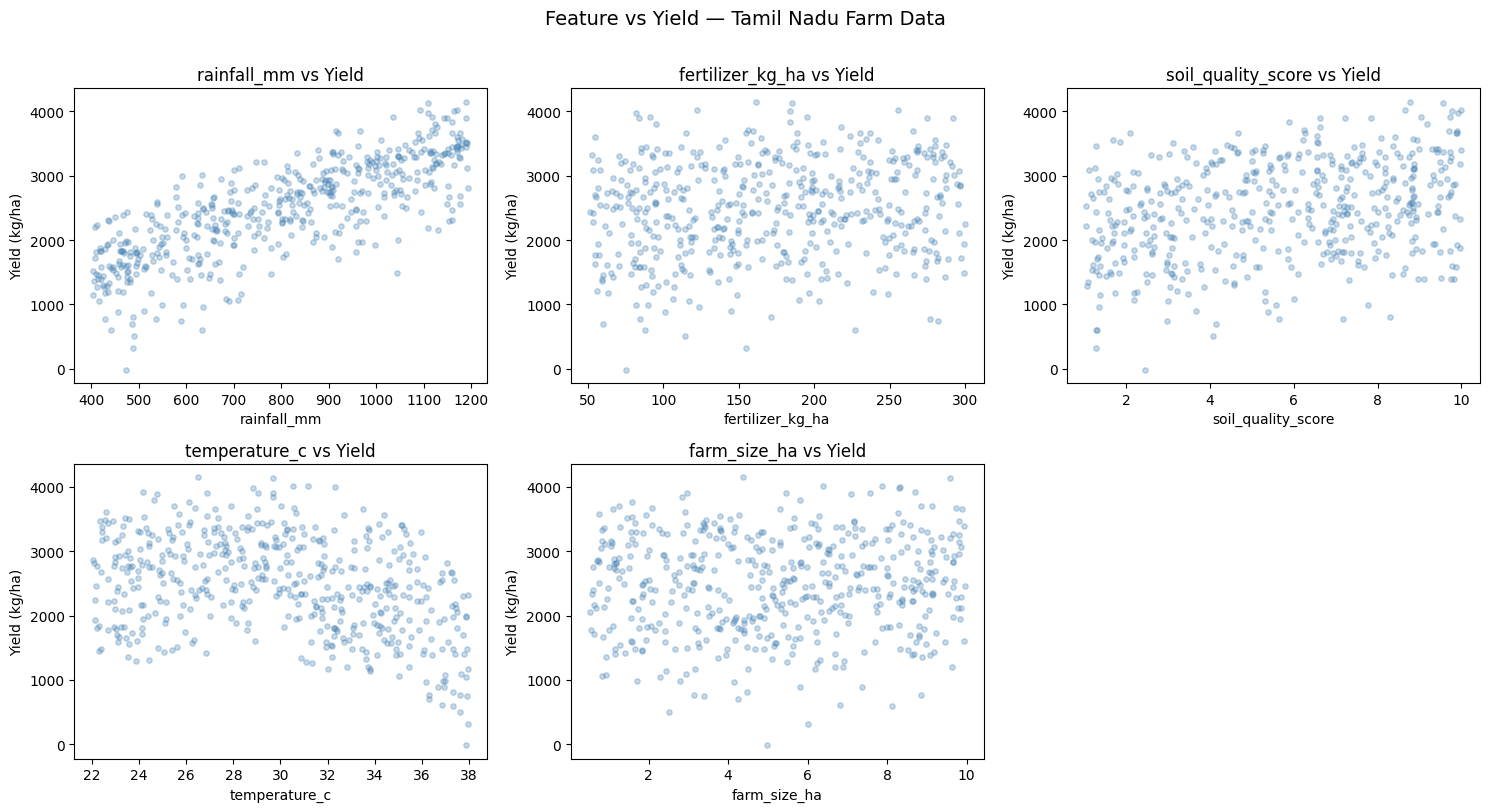

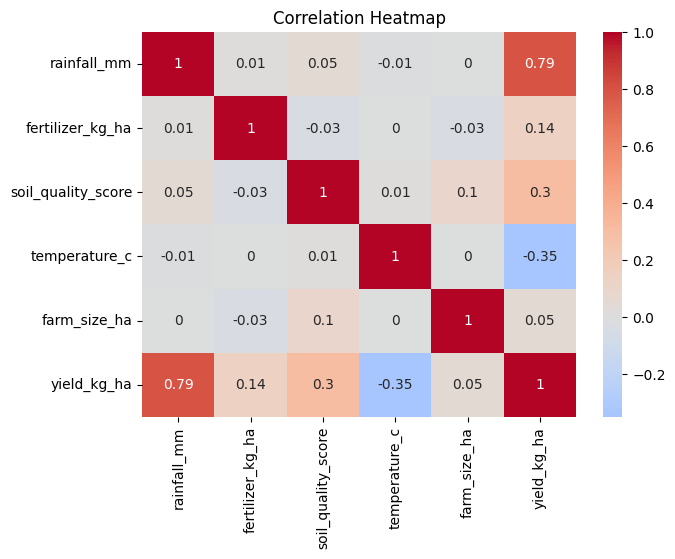

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features = ['rainfall_mm', 'fertilizer_kg_ha', 'soil_quality_score',
            'temperature_c', 'farm_size_ha']

for i, feat in enumerate(features):
    ax = axes[i // 3][i % 3]
    ax.scatter(df[feat], df['yield_kg_ha'], alpha=0.3, color='steelblue', s=15)
    ax.set_xlabel(feat)
    ax.set_ylabel('Yield (kg/ha)')
    ax.set_title(f'{feat} vs Yield')

axes[1][2].set_visible(False)
plt.suptitle('Feature vs Yield — Tamil Nadu Farm Data', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Look for:
# temperature_c: curved (inverted U) — peaks at 28 degrees
# fertilizer_kg_ha: slight curve — diminishing returns at high values

plt.figure(figsize=(7, 5))
sns.heatmap(df.corr().round(2), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

---
## Step 4: Train-Test Split + Scaling

**Why fit scaler on training data only?**

If we include test data in `fit_transform`, the scaler learns the mean and std of the full dataset — including the test set. That leaks information about future data into our preprocessing. The test set must stay completely unseen until evaluation.

In [4]:
X = df.drop('yield_kg_ha', axis=1)
y = df['yield_kg_ha']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # learn mean/std from train, apply to train
X_test_scaled  = scaler.transform(X_test)       # apply train's mean/std to test (no leakage)

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

Train: 400 samples | Test: 100 samples


---
## Step 5: Plain Gradient Boosting — Baseline

**What `.fit()` does internally:**
1. Start: predict mean of y for all samples
2. Compute residuals = y − ŷ (negative gradient of MSE)
3. Fit a shallow tree on residuals
4. Update: ŷ += learning_rate × tree prediction
5. Recompute residuals. Repeat for n_estimators trees.

This is exactly Rounds 1, 2, 3... from the walkthrough above.

In [5]:
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

gb_model.fit(X_train_scaled, y_train)
gb_preds = gb_model.predict(X_test_scaled)

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_preds))
gb_mae  = mean_absolute_error(y_test, gb_preds)
gb_r2   = r2_score(y_test, gb_preds)

print("=== Plain Gradient Boosting ===")
print(f"RMSE : {gb_rmse:.2f} kg/ha  (average prediction error)")
print(f"MAE  : {gb_mae:.2f} kg/ha  (median prediction error)")
print(f"R²   : {gb_r2:.4f}         (% variance explained — 1.0 = perfect)")

=== Plain Gradient Boosting ===
RMSE : 192.87 kg/ha  (average prediction error)
MAE  : 150.71 kg/ha  (median prediction error)
R²   : 0.9239         (% variance explained — 1.0 = perfect)


---
## Step 6: XGBoost

**What `.fit()` does differently at each split:**
1. Computes gradient g (direction of error) and Hessian h (curvature)
2. Computes exact Gain for every potential split using both g and h
3. Only splits if Gain > γ threshold — automatic pruning
4. Applies L1 (alpha) and L2 (lambda) penalties to leaf values
5. Uses histogram approximation — 256 buckets instead of all thresholds

**Hyperparameter reference:**

| Parameter | What it does | Increasing it... |
|---|---|---|
| `n_estimators` | Number of trees | Better accuracy, slower training |
| `learning_rate` | Each tree's weight | Smaller = safer, needs more trees |
| `max_depth` | Tree depth | Higher = more complex = overfit risk |
| `reg_alpha` | L1 penalty on leaves | More features zeroed out |
| `reg_lambda` | L2 penalty on leaves | More shrinkage, smoother model |
| `subsample` | Fraction of rows per tree | Less overfitting, more randomness |
| `colsample_bytree` | Fraction of features per tree | Less overfitting, more randomness |

In [6]:
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,       # same as GB for fair comparison
    max_depth=4,             # same as GB for fair comparison
    reg_alpha=0.1,           # L1: slight feature selection effect
    reg_lambda=1.0,          # L2: default; smooth leaf values
    subsample=0.8,           # each tree sees 80% of rows
    colsample_bytree=0.8,    # each tree sees 80% of features
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_train_scaled, y_train)
xgb_preds = xgb_model.predict(X_test_scaled)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_mae  = mean_absolute_error(y_test, xgb_preds)
xgb_r2   = r2_score(y_test, xgb_preds)

print("=== XGBoost ===")
print(f"RMSE : {xgb_rmse:.2f} kg/ha")
print(f"MAE  : {xgb_mae:.2f} kg/ha")
print(f"R²   : {xgb_r2:.4f}")

=== XGBoost ===
RMSE : 190.51 kg/ha
MAE  : 147.68 kg/ha
R²   : 0.9258


---
## Step 7: Side-by-Side Comparison

Same hyperparameters, same data, same split. Only the algorithm differs.
Any score difference = the algorithm's actual improvement.

                  Model  RMSE (kg/ha)  MAE (kg/ha)     R²
Plain Gradient Boosting        192.87       150.71 0.9239
                XGBoost        190.51       147.68 0.9258


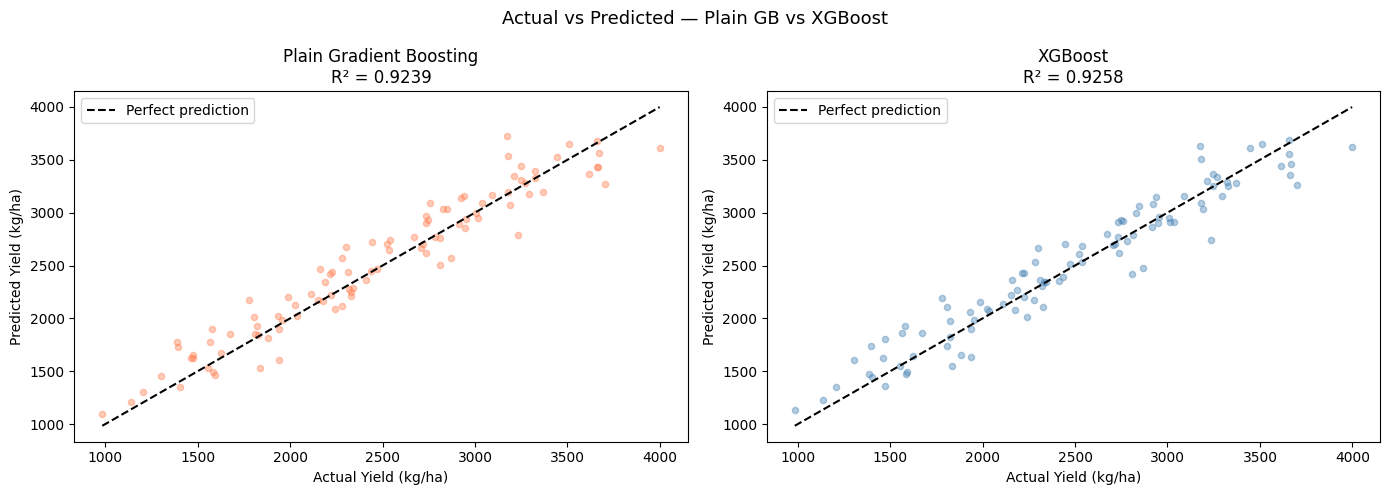

In [7]:
comparison = pd.DataFrame({
    'Model'       : ['Plain Gradient Boosting', 'XGBoost'],
    'RMSE (kg/ha)': [round(gb_rmse, 2), round(xgb_rmse, 2)],
    'MAE (kg/ha)' : [round(gb_mae, 2),  round(xgb_mae, 2)],
    'R²'          : [round(gb_r2, 4),   round(xgb_r2, 4)]
})
print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, preds, name, color in zip(
    axes,
    [gb_preds, xgb_preds],
    ['Plain Gradient Boosting', 'XGBoost'],
    ['coral', 'steelblue']
):
    ax.scatter(y_test, preds, alpha=0.4, color=color, s=20)
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual Yield (kg/ha)')
    ax.set_ylabel('Predicted Yield (kg/ha)')
    ax.set_title(f'{name}\nR² = {r2_score(y_test, preds):.4f}')
    ax.legend()
    # Points close to dashed line = accurate predictions
    # Scatter away from line = model is off on those samples

plt.suptitle('Actual vs Predicted — Plain GB vs XGBoost', fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 8: Feature Importance — What Drives Crop Yield?

XGBoost tracks three types of feature importance:

| Type | What it measures | Use when |
|---|---|---|
| `weight` | Times a feature was used to split | Quick overview |
| `gain` | Average loss reduction from splits using this feature | Most meaningful — use this |
| `cover` | Samples covered by splits on this feature | Dataset coverage |

We use **gain** — tells us which features actually improved predictions, not just which were picked often.

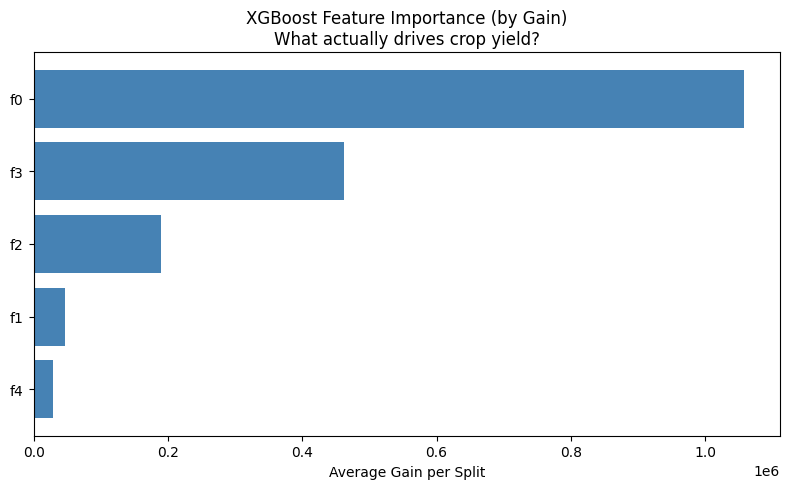

Higher gain = this feature contributed more to reducing prediction error.
Ravi can tell the Agriculture Department where to invest — irrigation vs fertilizer.


In [8]:
importance = xgb_model.get_booster().get_score(importance_type='gain')

feat_imp_df = pd.DataFrame(
    list(importance.items()), columns=['Feature', 'Gain']
).sort_values('Gain', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Gain'], color='steelblue')
plt.xlabel('Average Gain per Split')
plt.title('XGBoost Feature Importance (by Gain)\nWhat actually drives crop yield?')
plt.tight_layout()
plt.show()

print("Higher gain = this feature contributed more to reducing prediction error.")
print("Ravi can tell the Agriculture Department where to invest — irrigation vs fertilizer.")

---
## Step 9: Cross-Validation — Is Our Score Trustworthy?

A single 80/20 split can get lucky or unlucky based on which 20% lands in the test set.

**5-Fold CV:** split data into 5 equal parts. Train on 4, test on 1. Rotate 5 times. Average results.

Gives a more honest generalisation estimate — tested on 5 different slices.

In [9]:
X_scaled_full = scaler.fit_transform(X)

# neg_root_mean_squared_error: sklearn maximises scores, so it negates RMSE
# We flip the sign back to get positive RMSE values
cv_scores = cross_val_score(
    xgb_model, X_scaled_full, y,
    cv=5, scoring='neg_root_mean_squared_error'
)

cv_rmse = -cv_scores

print("XGBoost 5-Fold Cross-Validation RMSE:")
for i, score in enumerate(cv_rmse, 1):
    print(f"  Fold {i}: {score:.2f} kg/ha")
print(f"\nMean RMSE : {cv_rmse.mean():.2f} kg/ha")
print(f"Std  RMSE : {cv_rmse.std():.2f} kg/ha")
print("\nLow std = consistent across data slices = trustworthy score")
print("High std = sensitive to which data it sees = less reliable")

XGBoost 5-Fold Cross-Validation RMSE:
  Fold 1: 161.24 kg/ha
  Fold 2: 199.59 kg/ha
  Fold 3: 179.79 kg/ha
  Fold 4: 170.20 kg/ha
  Fold 5: 165.05 kg/ha

Mean RMSE : 175.17 kg/ha
Std  RMSE : 13.70 kg/ha

Low std = consistent across data slices = trustworthy score
High std = sensitive to which data it sees = less reliable


---
## Step 10: Learning Rate Experiment

**The confusion:** does small learning rate = underfitting?

**No.** Small LR means each tree contributes less. You need more trees. But each step is careful — doesn't overshoot.

Small LR + many trees = better generalisation. Not underfitting.

The chart below shows exactly this.

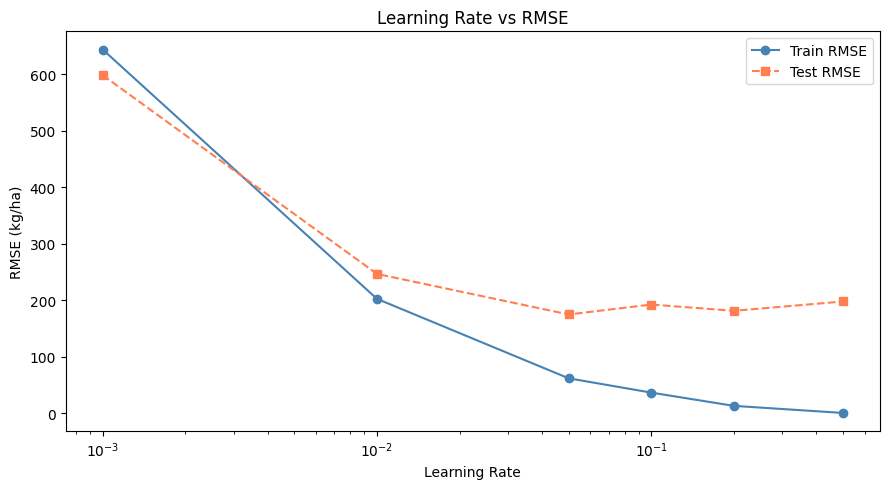

High LR (0.5):   train low, test high → overfitting
Low LR (0.001):  both high → not converged yet with only 200 trees
Fix for low LR:  increase n_estimators, not the learning rate
Sweet spot:      LR where test RMSE is lowest


In [10]:
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5]
train_rmses, test_rmses = [], []

for lr in learning_rates:
    m = xgb.XGBRegressor(n_estimators=200, learning_rate=lr,
                          max_depth=4, random_state=42, verbosity=0)
    m.fit(X_train_scaled, y_train)
    train_rmses.append(np.sqrt(mean_squared_error(y_train, m.predict(X_train_scaled))))
    test_rmses.append(np.sqrt(mean_squared_error(y_test,  m.predict(X_test_scaled))))

plt.figure(figsize=(9, 5))
plt.plot(learning_rates, train_rmses, 'o-', label='Train RMSE', color='steelblue')
plt.plot(learning_rates, test_rmses,  's--', label='Test RMSE',  color='coral')
plt.xlabel('Learning Rate')
plt.ylabel('RMSE (kg/ha)')
plt.title('Learning Rate vs RMSE')
plt.legend()
plt.xscale('log')
plt.tight_layout()
plt.show()

print("High LR (0.5):   train low, test high → overfitting")
print("Low LR (0.001):  both high → not converged yet with only 200 trees")
print("Fix for low LR:  increase n_estimators, not the learning rate")
print("Sweet spot:      LR where test RMSE is lowest")

---
## Step 11: Regularisation Experiment — See L2 in Action

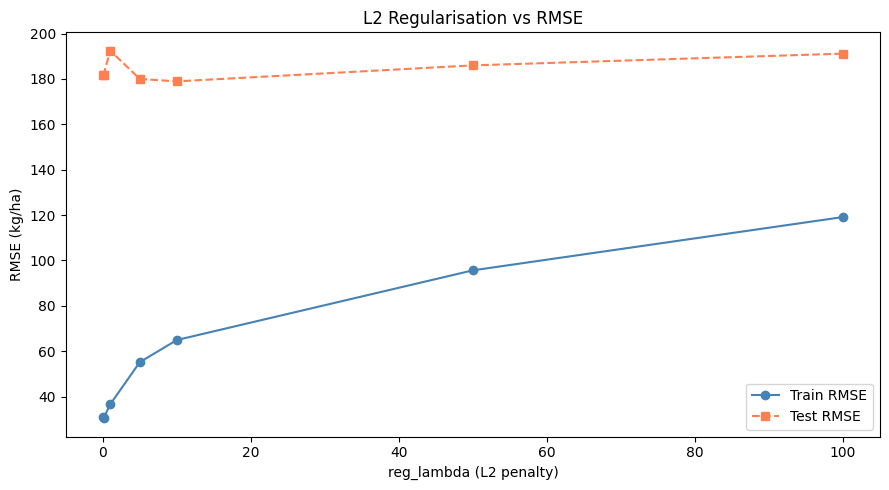

lambda=0:    no regularisation → overfitting risk
lambda high: too much shrinkage → both train and test RMSE go up
Sweet spot:  lambda where test RMSE is lowest


In [11]:
lambdas = [0, 0.1, 1, 5, 10, 50, 100]
train_r, test_r = [], []

for lam in lambdas:
    m = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1,
                          max_depth=4, reg_lambda=lam,
                          random_state=42, verbosity=0)
    m.fit(X_train_scaled, y_train)
    train_r.append(np.sqrt(mean_squared_error(y_train, m.predict(X_train_scaled))))
    test_r.append(np.sqrt(mean_squared_error(y_test,  m.predict(X_test_scaled))))

plt.figure(figsize=(9, 5))
plt.plot(lambdas, train_r, 'o-', label='Train RMSE', color='steelblue')
plt.plot(lambdas, test_r,  's--', label='Test RMSE',  color='coral')
plt.xlabel('reg_lambda (L2 penalty)')
plt.ylabel('RMSE (kg/ha)')
plt.title('L2 Regularisation vs RMSE')
plt.legend()
plt.tight_layout()
plt.show()

print("lambda=0:    no regularisation → overfitting risk")
print("lambda high: too much shrinkage → both train and test RMSE go up")
print("Sweet spot:  lambda where test RMSE is lowest")

---
## Final Summary

### Gradient Boosting

| Question | Answer |
|---|---|
| What does each tree learn? | Residuals = errors of current ensemble — target column is REPLACED with residuals each round |
| Why called gradient boosting? | Residual = negative gradient of MSE loss w.r.t. ŷ |
| Different from parameter gradient descent? | There we move weights. Here we add a tree (function). |
| Final prediction | T₁ + η·T₂ + η·T₃ + ... (SUM, not average) |
| Why not add full residual? | One shallow tree is noisy — adding full prediction overshoots. Small LR = cautious steps across many trees |
| Why use MSE not log loss? | Log loss needs probability output (0-1). Regression output is unbounded number. Different problem. |

### XGBoost Upgrades

| Upgrade | Plain GB | XGBoost | Where it acts |
|---|---|---|---|
| Split decision | Gradient only | Gradient + Hessian | At every split evaluation |
| Regularisation | Indirect | Direct (γ, λ, α in objective) | γ=split decision, λ/α=leaf values |
| Missing values | Manual | Automatic default direction | At split routing |
| Speed | All thresholds | Histogram (256 bins) | Before split-finding |
| Subsampling | No | Yes (rows + columns) | Before each tree is built |

### The Three Regularisers

| Parameter | What it does | Effect of increasing it |
|---|---|---|
| γ (gamma) | Minimum gain to make a split | Shallower trees — blocks deep low-gain splits first |
| λ (reg_lambda) | L2 penalty on leaf values | Shrinks all leaf scores toward zero — like Ridge |
| α (reg_alpha) | L1 penalty on leaf values | Zeros out weak leaves entirely — like Lasso |

### Why λ Penalising the Leaf Score Helps

| Situation | Without λ | With λ |
|---|---|---|
| 3 rows in leaf, residuals≈80 | Predicts 80 confidently | Predicts 40 conservatively |
| New data, true residual=55 | Error=25 (overshot) | Error=15 (undershot, but next tree corrects) |
| New data, true residual=105 | Error=25 (undershot) | Error=65 (bigger undershot, but consistent) |
| Average across all rounds | High variance, overfits | Low variance, generalises |

λ doesn't guarantee less error on every single row. It guarantees less error ON AVERAGE by reducing overconfidence from small samples.

### Gain Formula — Reading It

```
Gain = GL²/(HL+λ) + GR²/(HR+λ) - (GL+GR)²/(HL+HR+λ) - γ
       ───────────   ───────────   ─────────────────────   ─
       left score    right score   parent score (before)   cost of splitting

Gain > 0 → split improves predictions → make the split
Gain ≤ 0 → not worth splitting → node becomes a leaf
G²/H     → score of a group = how much loss can be reduced by predicting -G/H
H in denominator → uncertainty measure — large H = many points = less aggressive split
```

### When to Use XGBoost

| Situation | Recommendation |
|---|---|
| Tabular data, regression or classification | XGBoost — almost always top performer |
| Missing values in dataset | XGBoost handles natively |
| Need feature importance | XGBoost: gain / weight / cover |
| Need full interpretability | Linear Regression or single Decision Tree |
| Image / text / sequence data | Neural networks — XGBoost not suited |

---
## Practice Tasks

**Task 1:** Set `reg_alpha=5.0` (strong L1). Check feature importance — do any features get zeroed out?

**Task 2:** Set `subsample=1.0` and `colsample_bytree=1.0`. Compare train vs test RMSE — does the gap widen? What does that mean?

**Task 3:** Add feature `irrigation_score` (random uniform 1–10) with NO actual effect on yield. Does XGBoost give it near-zero importance?

**Task 4 (challenge):** Set `learning_rate=0.01, n_estimators=2000` vs `learning_rate=0.1, n_estimators=200`. Which gets better test RMSE? Why?

In [ ]:
# Task 1: Strong L1
# YOUR CODE HERE

# Task 2: No subsampling
# YOUR CODE HERE

# Task 3: Noise feature
# YOUR CODE HERE

# Task 4: Small LR + many trees vs large LR + few trees
# YOUR CODE HERE